In [3]:
# For reference i use AMG GPU on my pc so i dont have access to CUSA and have no interest in setting up ROCm for this simple exercise
import torch
import torchvision
import matplotlib.pyplot as plt

# check torch version
print(torch.__version__)
print("CUDA available: ", torch.cuda.is_available())

2.12.0+cu130
CUDA available:  False


In [7]:
# import datasets, will be using MNIST
# transforms basically rescales these images from 0-255 scale to 0-1 scale
from torchvision import datasets, transforms

transform = transforms.ToTensor()

# MNIST dataset was made in a way that train set is different from test set
# and also test set is the always same so comparison is easier to make
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(len(train_data), len(test_data))

60000 10000


In [8]:
# take the first image from dataset to look at the data
image, label = train_data[0]
print(image.shape)
print(label)
print(image.min(), image.max())

torch.Size([1, 28, 28])
5
tensor(0.) tensor(1.)


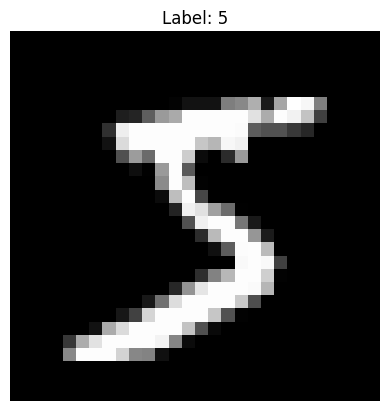

In [9]:
# basically show the image
# also .squeeze() makes image.shape from [1,28,28] to [28,28] so it can be printed
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

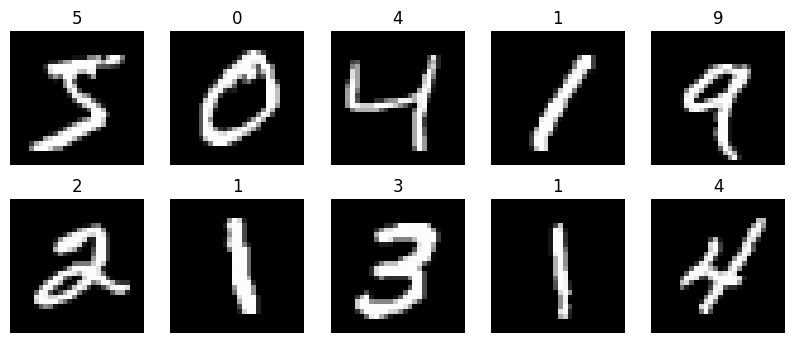

In [13]:
# just show a 2x5 grid of images from MNIST
fig, axes = plt.subplots(2, 5, figsize=(10, 4)) # plt.subplots creates a 2x5 grid

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.show()

In [17]:
import torch.nn as nn

# conv1 and conv2 are 2 convolution layes
# conv1 is a layer that takes in input the image that needs to be guessed, applies a 32 different 3x3 kernels (kernel values are the weights)
# over the image that was give in input and produced 32 feature maps in output
# Conv2d makes 32 different kernels, kernel values are basically weights that slide over the image to produce one feature map in the end and based on output the weights are being changes, basically training.

class CNN(nn.Module):
    # define layers inside init
    def __init__(self):
        super().__init__()
        # first convolution to spot simple patterns
        self.conv1 = nn.Conv2d(1, 32, 3)
        # second convolution to spot more difficult patterns like circles (in number like 6, 9 or 8), lines (in numbers like 1, 4 or 7), etc.
        self.conv2 = nn.Conv2d(32, 64, 3)
        # basically take each 2x2 pixel block in the feature map and keep only the highest value from the 2x2 block to produce a smaller feature map (just easier to process)
        self.pool = nn.MaxPool2d(2) # 26x26 become 13x13
        # define 2 hidden layers 1600 are basically input neurons like 64 feature maps from second convolution multiplied by 6x6 pixels for each feature map which is 1600
        # also 128 neuron layer, ion know why 128, just felt like it
        # 10 is the output layer, the result we want is a decision on a 0-9 number
        self.fc1 = nn.Linear(1600, 128)
        self.fc2 = nn.Linear(128, 10)

    # how data flows through the layers
    def forward(self, x):
        # ReLU ( Rectified Linear Unit) a non linear activation function
        # first convolution + 26x26 -> 13x13 pool + ReLU
        x = self.conv1(x)
        x = self.pool(x)
        x = torch.relu(x)

        # second convolution + 13x13 -> 6x6 pool + ReLU
        x = self.conv2(x)
        x = self.pool(x)
        x = torch.relu(x)

        # flatten to 1600
        x = x.view(x.size(0), -1)

        # feed 1600 values and get 128 activations in return + ReLU
        x = self.fc1(x)
        x = torch.relu(x)

        # final 128 neurons to 10, basically final decision
        x = self.fc2(x)
        return x

In [18]:
import torch

model = CNN()
test = torch.randn(1, 1, 28, 28) # fake image
output = model(test)
print(output.shape)

torch.Size([1, 10])


In [20]:
from torch.utils.data import DataLoader

# DataLoader splits the train set of 60000 into batches, in this case 64 images, so 64 images are being fed to neural network
# shuffle is used to prevent neural network from memorizing results
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [21]:
import torch.optim as optim

# optimizer is the object that actually updates the weights, it hold the models weights via a model.parameters() reference
# and when update of the weights is needed optimizer.step() can be called
# model.parameters() returns learnable weights
model = CNN()
criterion = nn.CrossEntropyLoss() # CrossEntropyLoss most basic loss function
optimizer = optim.SGD(model.parameters(), lr=0.01) # lr - learning rate, basically move weights 1% each iteration

Epoch 1, Loss: 41.8568
Epoch 2, Loss: 40.0006
Epoch 3, Loss: 37.8016
Epoch 4, Loss: 36.1167
Epoch 5, Loss: 34.4611
Epoch 6, Loss: 33.1234
Epoch 7, Loss: 31.5295
Epoch 8, Loss: 30.4459
Epoch 9, Loss: 28.8471
Epoch 10, Loss: 27.9671


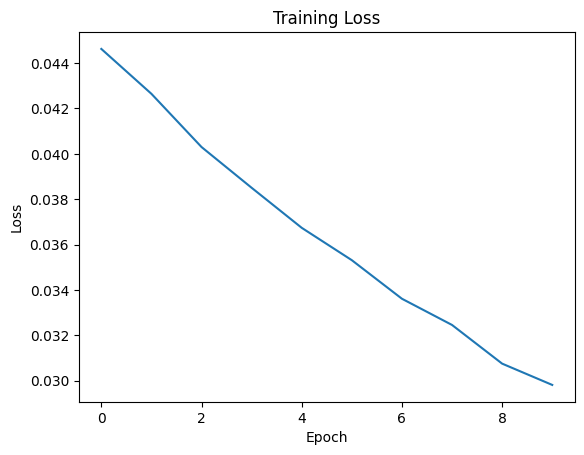

In [26]:
epochs = 10
loss_history = [] # to track losses for each batch

for epoch in range(epochs):
    # represents the total epoch loss
    running_loss = 0.0

    # loop through the dataset using data loader
    for images, labels in train_loader:
        # zero the gradients, basically reset gradients from the previous batch because pytorch caches them by default
        optimizer.zero_grad()
        # feed a batch of images to the model
        outputs = model(images)
        # compute loss on current batch outputs
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        # backward pass, basically indicate in which direction should the neural network go to reduce loss
        loss.backward()
        # update the weights
        optimizer.step()
        pass

    loss_history.append(running_loss/len(train_loader))
    
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()